<a href="https://colab.research.google.com/github/KijoSal-dev/Deep_Learning/blob/main/Salome_Kungu_CS_DA03_26054_WK10_Deep_Learning_ipynbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Step 2: Load Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training Shape: {X_train.shape}, Label shape: {y_train.shape}")
print(f"Test Shape: {X_test.shape}, Label shape: {y_train.shape}")

Training Shape: (60000, 28, 28), Label shape: (60000,)
Test Shape: (10000, 28, 28), Label shape: (60000,)


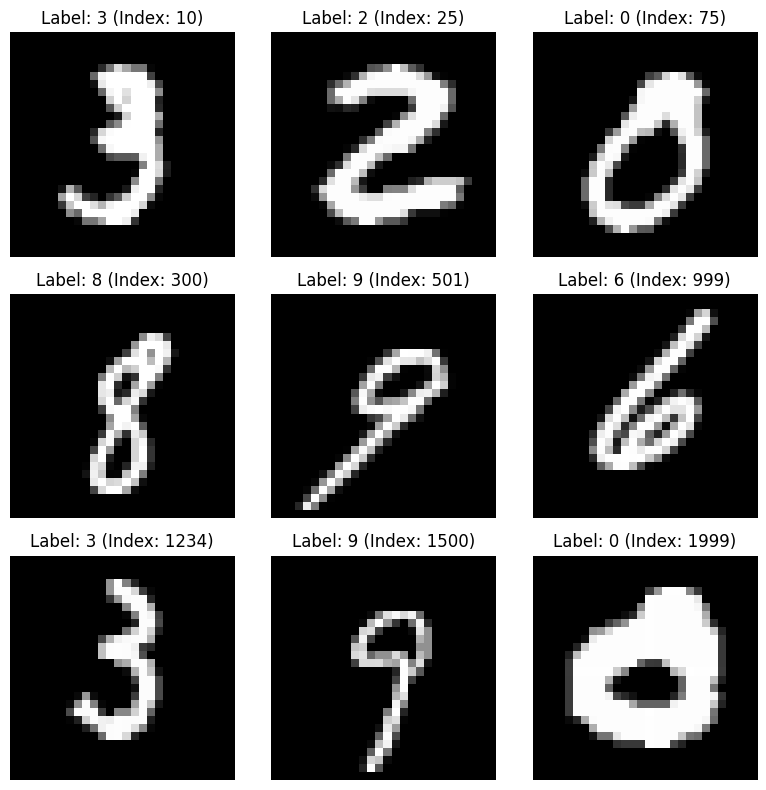

In [ ]:
# Step 3: Preprocess the Data
X_train = X_train / 255.0  # Normalize pixel values to [0,1]
X_test = X_test / 255.0
y_train_cat = to_categorical(y_train, 10)  # One-hot encode labels
y_test_cat = to_categorical(y_test, 10)

# Plot some digits from dataset
# Visualize sample images
selected_indices = [10, 25, 75, 300, 501, 999, 1234, 1500, 1999]  # Choose which image indices to display

plt.figure(figsize=(8, 8))

for i, idx in enumerate(selected_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]} (Index: {idx})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Step 4: Build the ANN Model

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Step 5: Compile the Model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Step 6: Train the Model

history = model.fit(X_train, y_train_cat, epochs=10, batch_size= 128, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4594 - loss: 5.3521 - val_accuracy: 0.7458 - val_loss: 0.9280
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6366 - loss: 1.2557 - val_accuracy: 0.8583 - val_loss: 0.6162
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7210 - loss: 0.9978 - val_accuracy: 0.8735 - val_loss: 0.5287
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7617 - loss: 0.8388 - val_accuracy: 0.9120 - val_loss: 0.4031
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7975 - loss: 0.7082 - val_accuracy: 0.9207 - val_loss: 0.3100
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8162 - loss: 0.6047 - val_accuracy: 0.9300 - val_loss: 0.2698
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8439 - loss: 0.5472 - val_accuracy: 0.9387 - val_loss: 0.2714
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8585 - loss: 0.4953 - val_accuracy: 

In [ ]:
from IPython.testing import test
# Step 7: Evaluate on test set

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9343 - loss: 0.2564
Test Accuracy: 0.9343000054359436


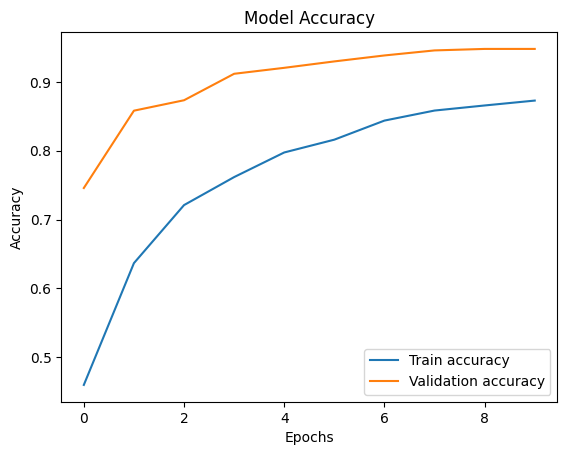

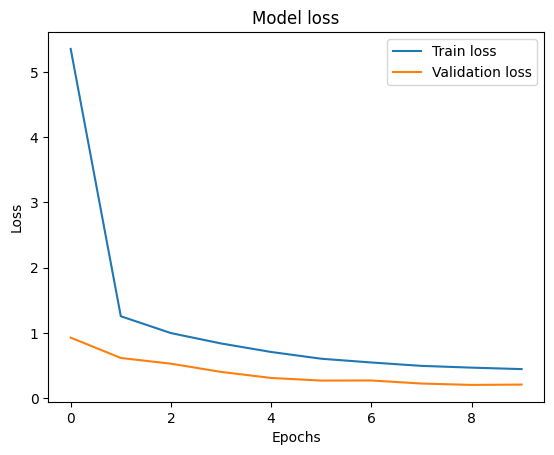

In [ ]:
# Step 8 : Visualize and plot
# Training Model Accuracy
plt.plot(history.history['accuracy'], label = 'Train accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


#Train Model Loss
plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


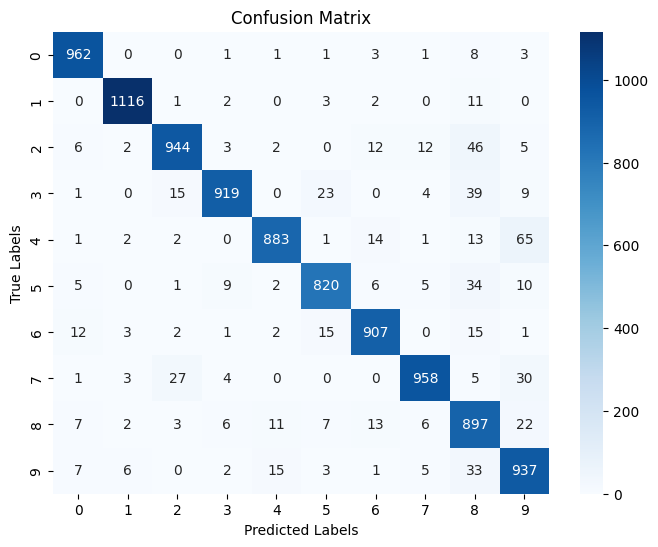

In [ ]:
# Step 9: Confusion Matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [ ]:
# Step 10: Classification Report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.91      0.93      1032
           3       0.97      0.91      0.94      1010
           4       0.96      0.90      0.93       982
           5       0.94      0.92      0.93       892
           6       0.95      0.95      0.95       958
           7       0.97      0.93      0.95      1028
           8       0.81      0.92      0.86       974
           9       0.87      0.93      0.90      1009

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000



In [ ]:
# Step 11 : Save Model

model.save("mnist_ann_model.h5")

In [ ]:
# Step 12: Reload Model

from tensorflow.keras.models import load_model
reloaded_model = load_model("mnist_ann_model.h5")
reloaded_model.evaluate(X_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9343 - loss: 0.2564


[0.25636059045791626, 0.9343000054359436]